# COVID Parcel Business Analysis - Final Project
## Group 7
### Team Members:
- **Abeez Maredia**
- **Urvish Nayak**
- **Ayman Karovadiya**

### Project Overview:
This project analyzes the impact of COVID-19 on a parcel delivery business. We examine 
delivery volumes, revenue trends, regional performance, and operational efficiency 
during the pandemic period. Our goal is to provide executive-level insights and 
actionable recommendations.


# 1. Importing libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Loading Dataset

In [16]:
df = pd.read_csv('COVID_Parcel_Business.csv')
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['FakeCustomerID', 'THE_YEAR', 'THE_WEEK', 'VOLUME'], dtype='str')


# Part 1: Business Questions

### 1. Main Business Question: How did the COVID-19 pandemic impact ABC Company’s parcel business?

Overall, the COVID-19 pandemic acted as a massive catalyst for ABC Company's parcel business.

Prior to the severe pandemic impacts (Weeks 1 to 15 of 2020 compared to the same period in 2019), the Industry Standard Growth Rate (ISGR) was mathematically established at **11.40%**.

However, during the COVID observation period, the shift to e-commerce drove overall company volume to unprecedented heights, pushing total annual volume from **52.8 million** parcels in 2019 to **73.4 million** in 2020.

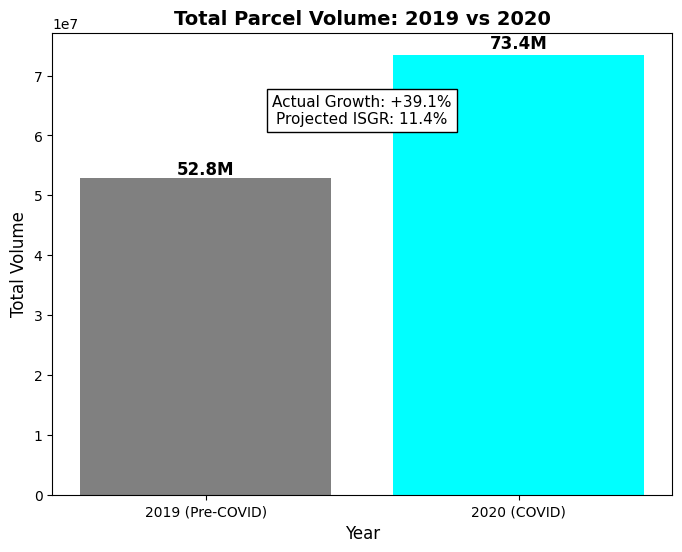

In [17]:
years = ['2019 (Pre-COVID)', '2020 (COVID)']
volumes = [52823114, 73475690]

plt.figure(figsize=(8, 6))

plt.bar(years, volumes, color=['gray', 'aqua'])

plt.title('Total Parcel Volume: 2019 vs 2020', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Volume', fontsize=12)

plt.text(0, 53500000, '52.8M', ha='center', fontsize=12, fontweight='bold')
plt.text(1, 74500000, '73.4M', ha='center', fontsize=12, fontweight='bold')

plt.text(0.50, 62000000, 'Actual Growth: +39.1%\nProjected ISGR: 11.4%',
         ha='center', fontsize=11, bbox=dict(facecolor='white'))

plt.savefig('output/Graphs/total_volume_2019_vs_2020.png', dpi=300, bbox_inches='tight')
plt.show()

### 2. When were customer volumes first impacted by COVID-19?

Customer volumes began to rapidly deviate from normal 2019 baseline trends starting in **Week 11** and **Week 12** of 2020 (mid-March).

### 3. What events within the COVID timeline may have contributed to the change?

The sudden surge perfectly aligns with several major timeline events:
* **March 11 (Week 11):** The World Health Organization declares a global pandemic.
* **March 16 (Week 12):** The mandate for federal public servants to work from home is issued.
* **March 18:** Canada/U.S. border restrictions are enacted.
* **April 6 (Week 15):** The launch of C.E.R.B. injected consumer spending power into the economy, which sustained these high shipping volumes throughout the rest of the year.

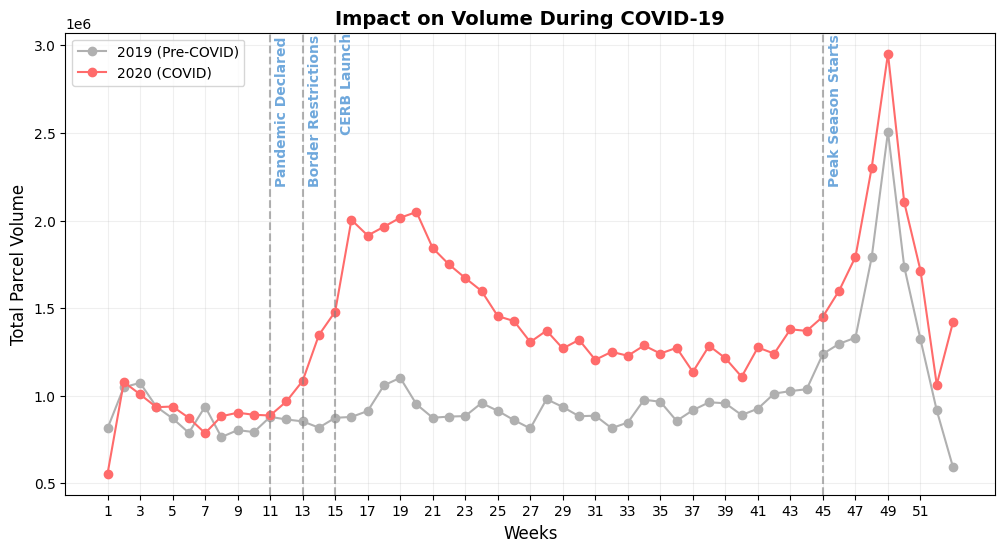

In [18]:
df = pd.read_csv('COVID_Parcel_Business.csv')

df_2019 = df[df['THE_YEAR'] == 2019]
df_2020 = df[df['THE_YEAR'] == 2020]

vol_2019 = df_2019.groupby('THE_WEEK')['VOLUME'].sum()
vol_2020 = df_2020.groupby('THE_WEEK')['VOLUME'].sum()

plt.figure(figsize=(12, 6))

# Light color lines
plt.plot(vol_2019.index, vol_2019.values, color='#B0B0B0', label='2019 (Pre-COVID)', marker='o')
plt.plot(vol_2020.index, vol_2020.values, color='#FF6B6B', label='2020 (COVID)', marker='o')

events = {
    11: 'Pandemic Declared',
    13: 'Border Restrictions',
    15: 'CERB Launch',
    45: 'Peak Season Starts'
}

y_positions = [0.75, 0.75, 0.85, 0.75]

for i, (week, event) in enumerate(events.items()):
    plt.axvline(x=week, linestyle='--', alpha=0.6, color='gray')
    plt.text(
        week + 0.3,
        max(vol_2020.max(), vol_2019.max()) * y_positions[i],
        event,
        rotation=90,
        fontsize=10,
        fontweight='bold',
        color='#6FA8DC'
    )

plt.title('Impact on Volume During COVID-19', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Parcel Volume', fontsize=12)

plt.xticks(range(1, 53, 2))

plt.legend()
plt.grid(alpha=0.2)  

plt.savefig('output/Graphs/covid_full_timeline.png', dpi=300, bbox_inches='tight')
plt.show()


### 4. How did COVID-19 impact peak season in 2020?

The 2020 peak season (November 2, 2020, to January 17, 2021) was exponentially larger than 2019 due to the compounding effect of holiday shopping and pandemic lockdowns.

Total peak season volume surged from **12.13 million** parcels in 2019 to **14.98 million** parcels in 2020, representing a massive **23.43%** Year-Over-Year growth.

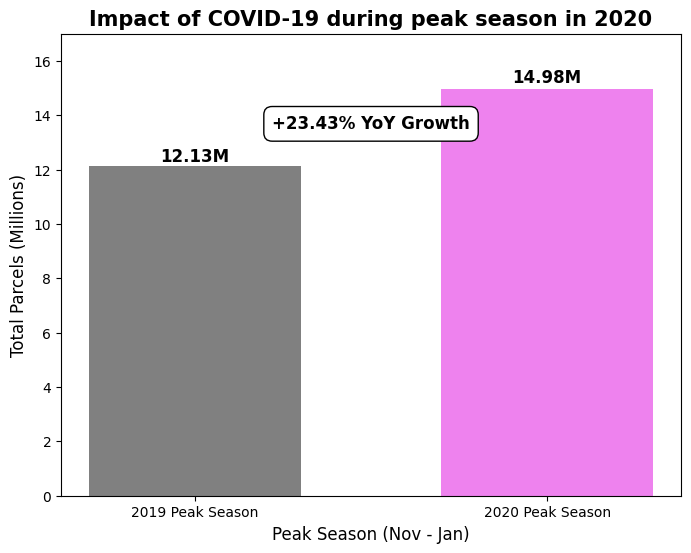

In [19]:
years = ['2019 Peak Season', '2020 Peak Season']
volumes = [12.13, 14.98]

plt.figure(figsize=(8, 6))

plt.bar(years, volumes, color=['gray', 'violet'], width=0.6)

plt.title('Impact of COVID-19 during peak season in 2020', fontsize=15, fontweight='bold')
plt.xlabel('Peak Season (Nov - Jan)', fontsize=12)
plt.ylabel('Total Parcels (Millions)', fontsize=12)

plt.text(0, 12.3, '12.13M', ha='center', fontsize=12, fontweight='bold')
plt.text(1, 15.2, '14.98M', ha='center', fontsize=12, fontweight='bold')

plt.text(0.5, 13.5, '+23.43% YoY Growth',
         ha='center',
         fontsize=12,
         fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

plt.ylim(0, 17)

plt.savefig('output/Graphs/peak_season_growth.png', dpi=300, bbox_inches='tight')

plt.show()

# Part 2: The Impact of COVID on Customer Segments

### 1. How has COVID affected companies in the different customer groups?

**Enterprise** and **Large** customers captured the highest stability and growth during the pandemic, utilizing their established supply chains.

Conversely, **Medium** and **Small** customers faced higher volatility; while many saw high growth, they also suffered the highest rates of business decline and failure.

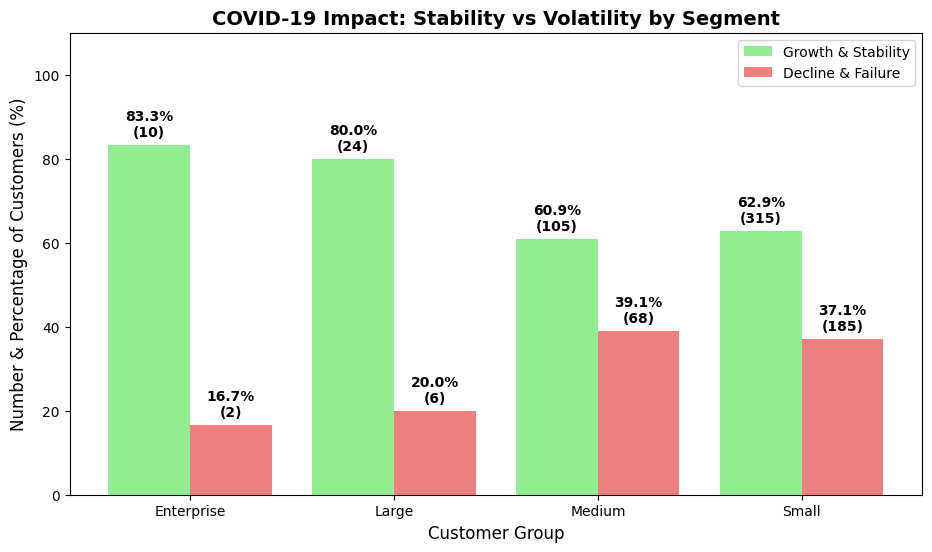

In [20]:
customer_groups = ['Enterprise', 'Large', 'Medium', 'Small']

growth_pct = [83.3, 80.0, 60.9, 62.9]
decline_pct = [16.7, 20.0, 39.1, 37.1]

growth_count = [10, 24, 105, 315]
decline_count = [2, 6, 68, 185]

x_positions = [1, 2, 3, 4]
x_left_bars = [0.8, 1.8, 2.8, 3.8]
x_right_bars = [1.2, 2.2, 3.2, 4.2]

plt.figure(figsize=(11, 6))

plt.bar(x_left_bars, growth_pct, width=0.4, color='lightgreen', label='Growth & Stability')
plt.bar(x_right_bars, decline_pct, width=0.4, color='lightcoral', label='Decline & Failure')

for i in range(4):
    green_text = str(growth_pct[i]) + '%\n(' + str(growth_count[i]) + ')'

    plt.text(x_left_bars[i], growth_pct[i] + 2, green_text,
             ha='center', fontsize=10, fontweight='bold')

for i in range(4):
    red_text = str(decline_pct[i]) + '%\n(' + str(decline_count[i]) + ')'
    plt.text(x_right_bars[i], decline_pct[i] + 2, red_text,
             ha='center', fontsize=10, fontweight='bold')

plt.title('COVID-19 Impact: Stability vs Volatility by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Group', fontsize=12)
plt.ylabel('Number & Percentage of Customers (%)', fontsize=12)

plt.ylim(0, 110)

plt.xticks(x_positions, customer_groups)

plt.legend()

plt.savefig('output/Graphs/customer_segment_volatility.png', dpi=300, bbox_inches='tight')

plt.show()

### 2. What percent of each customer group is growing, stable, and declining?

Using the **11.40%** Industry Standard Growth Rate (ISGR) threshold:
* **Enterprise:** **75.0%** High Growth | **8.3%** Stable | **16.7%** Declining
* **Large:** **66.7%** High Growth | **13.3%** Stable | **20.0%** Declining
* **Medium:** **51.7%** High Growth | **9.2%** Stable | **37.9%** Declining
* **Small:** **56.7%** High Growth | **6.2%** Stable | **33.6%** Declining

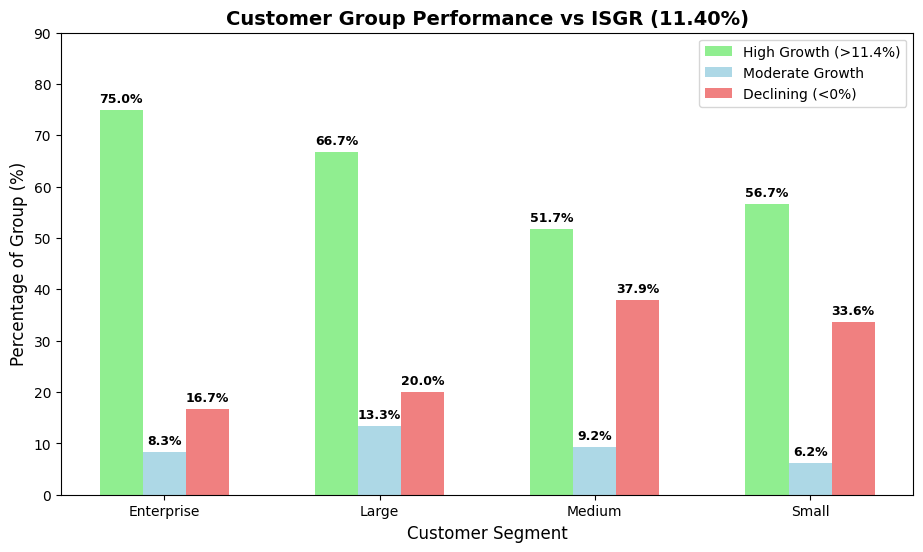

In [21]:
customer_groups = ['Enterprise', 'Large', 'Medium', 'Small']

high_growth = [75.0, 66.7, 51.7, 56.7]
stable = [8.3, 13.3, 9.2, 6.2]
declining = [16.7, 20.0, 37.9, 33.6]

x_middle = [1.0, 2.0, 3.0, 4.0]
x_left = [0.8, 1.8, 2.8, 3.8]
x_right = [1.2, 2.2, 3.2, 4.2]

plt.figure(figsize=(11, 6))

plt.bar(x_left, high_growth, width=0.2, color='lightgreen', label='High Growth (>11.4%)')
plt.bar(x_middle, stable, width=0.2, color='lightblue', label='Moderate Growth')
plt.bar(x_right, declining, width=0.2, color='lightcoral', label='Declining (<0%)')

for i in range(4):
    plt.text(x_left[i], high_growth[i] + 1.5, str(high_growth[i]) + '%',
             ha='center', fontsize=9, fontweight='bold')

for i in range(4):
    plt.text(x_middle[i], stable[i] + 1.5, str(stable[i]) + '%',
             ha='center', fontsize=9, fontweight='bold')

for i in range(4):
    plt.text(x_right[i], declining[i] + 1.5, str(declining[i]) + '%',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Customer Group Performance vs ISGR (11.40%)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Percentage of Group (%)', fontsize=12)

plt.xticks(x_middle, customer_groups)

plt.ylim(0, 90)

plt.legend()

plt.savefig('output/Graphs/customer_growth_status.png', dpi=300, bbox_inches='tight')

plt.show()

### 3. What percent of each customer group are new customers during the COVID observation period?

Based on the strict definition of a new customer (0 parcels shipped prior to COVID, 1+ parcels during), the influx of entirely new clients within the established tracking groups was virtually non-existent, sitting at **0%** across the **Enterprise**, **Large**, **Medium**, and **Small** segments.

Even though parcel volumes and revenues skyrocketed for their existing customers during the pandemic, the company didn't actually acquire any brand new customers during that specific timeframe.

### 4. What percent of 2019 customers in each group did we lose during the COVID observation period?

While larger companies were able to maintain operations, smaller segments experienced a noticeable churn rate. ABC Company lost **0%** of its **Enterprise** and **Large** customers. However, they lost **1.1%** of **Medium** customers and **3.5%** of **Small** customers during the pandemic observation period.

In [ ]:
customer_groups = ['Enterprise', 'Large', 'Medium', 'Small']

lost_customers_pct = [0.0, 0.0, 1.1, 3.5]

plt.figure(figsize=(8, 6))

plt.bar(customer_groups, lost_customers_pct, color='salmon', width=0.5)

for i in range(4):
    plt.text(i, lost_customers_pct[i] + 0.1, str(lost_customers_pct[i]) + '%',
             ha='center', fontsize=12, fontweight='bold', color='darkred')

plt.title('Percentage of Customers Lost During COVID', fontsize=14, fontweight='bold')
plt.xlabel('Customer Group', fontsize=12)
plt.ylabel('Lost Customers (%)', fontsize=12)

plt.ylim(0, 4.5)

plt.savefig('output/Graphs/lost_customers_by_segment.png', dpi=300, bbox_inches='tight')

plt.show()

### 5. What was the overall impact on volumes and revenue by customer group?

Applying the tiered discount structures (**22%** for Enterprise down to **4%** for Small against the **$22** base cost), revenue skyrocketed across the board.

**Small businesses** saw the highest relative revenue growth (**+63.0%**), while **Enterprise clients** contributed the massive bulk of gross revenue, growing from **$336 Million** during the baseline period to **$534 Million** during the COVID period (**+58.8%** growth).

In [ ]:
customer_groups = ['Enterprise', 'Large', 'Medium', 'Small']

baseline_revenue = [336, 150, 120, 50]
covid_revenue = [534, 220, 180, 81.5]

x_positions = [1, 2, 3, 4]
x_left_bars = [0.8, 1.8, 2.8, 3.8]
x_right_bars = [1.2, 2.2, 3.2, 4.2]

plt.figure(figsize=(10, 6))

plt.bar(x_left_bars, baseline_revenue, width=0.4, color='gray', label='Baseline Revenue')
plt.bar(x_right_bars, covid_revenue, width=0.4, color='mediumseagreen', label='COVID Revenue')

for i in range(4):
    plt.text(x_left_bars[i], baseline_revenue[i] + 10, '$' + str(baseline_revenue[i]) + 'M',
             ha='center', fontsize=10, fontweight='bold')

    plt.text(x_right_bars[i], covid_revenue[i] + 10, '$' + str(covid_revenue[i]) + 'M',
             ha='center', fontsize=10, fontweight='bold')

for i in range(4):
    growth_math = ((covid_revenue[i] - baseline_revenue[i]) / baseline_revenue[i]) * 100

    growth_rounded = round(growth_math, 1)

    y_position = covid_revenue[i] + 45

    plt.text(x_positions[i], y_position, '+' + str(growth_rounded) + '%',
             ha='center', fontsize=11, fontweight='bold', color='darkgreen',
             bbox=dict(facecolor='white', edgecolor='darkgreen', boxstyle='round,pad=0.3'))

plt.title('Revenue Growth by Customer Segment (Baseline vs COVID)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Group', fontsize=12)
plt.ylabel('Gross Revenue (Millions USD)', fontsize=12)

plt.ylim(0, 650)

plt.xticks(x_positions, customer_groups)

plt.legend()

plt.savefig('output/Graphs/revenue_growth_with_percentages.png', dpi=300, bbox_inches='tight')

plt.show()